In [1]:
import numpy as np
import scipy as sp
import krylov as kr
import ham_generator as gen
import matplotlib.pyplot as plt
import networkx as nx


In [2]:
#returns the analytical time averaged complexity for a complete graph with adjacency matrix
def analytic_compl_adj(dim):
    return 2.*(dim-1)/dim**2

In [3]:
def get_complexity(H, psi_0):
    try:
        base, new_H = kr.lanczos(H, psi_0)
    except ValueError as e:
        print(e)
    
    try:
        compl = kr.compl_inf_time(new_H)
    except ValueError as e:
        print(e)

    return new_H, compl

In [4]:
d_max = 30
an_x = np.linspace(3, d_max, d_max-2, dtype=int)
an_y = analytic_compl_adj(an_x)

compl = np.zeros(an_x.shape)
for i in an_x:
    H = gen.adjacency_matrix(nx.complete_graph(i))
    initial = np.zeros(i, dtype=complex)
    initial[0] = 1.0+0.j
    #initial = np.ones(i, dtype=complex)
    new_H, compl[i-3] = get_complexity(H, initial)

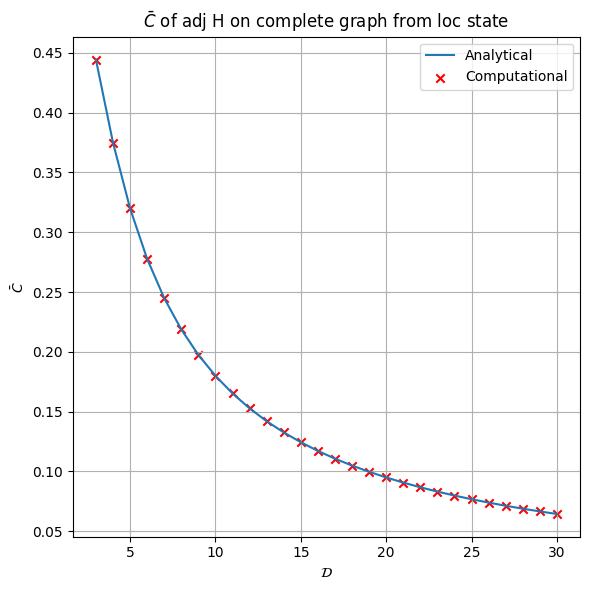

In [5]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.grid(True)
axx.plot(an_x,an_y, label="Analytical")
axx.scatter(an_x, compl, label="Computational", marker="x", color="r")
axx.set_title(r"$\bar{C}$ of adj H on complete graph from loc state")
axx.set_ylabel(r"$\bar{C}$")
axx.set_xlabel(r"$\mathcal{D}$")
axx.legend()

In [6]:
d_max = 30
an_x = np.linspace(3, d_max, d_max-2, dtype=int)
an_y_chain = (an_x-1.)/2.

compl_chain = np.zeros(an_x.shape)
for i in an_x:
    H_chain = gen.adjacency_matrix(nx.path_graph(i))
    initial = np.zeros(i, dtype=complex)
    initial[0] = 1.0+0.j
    #initial = np.ones(i, dtype=complex)
    new_H, compl_chain[i-3] = get_complexity(H_chain, initial)

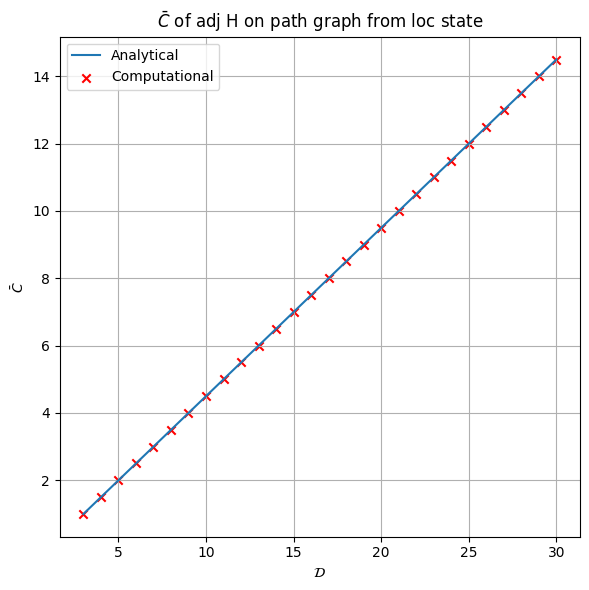

In [7]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.grid(True)
axx.plot(an_x,an_y_chain, label="Analytical")
axx.scatter(an_x, compl_chain, label="Computational", marker="x", color="r")
#axx.plot(an_x, np.abs(an_y_chain-compl_chain))
axx.set_title(r"$\bar{C}$ of adj H on path graph from loc state")
axx.set_ylabel(r"$\bar{C}$")
axx.set_xlabel(r"$\mathcal{D}$")
axx.legend()

In [8]:
d_max = 50
an_x = np.linspace(3, d_max, d_max-2, dtype=int)
an_y_cycle_even = an_x/4.
an_y_cycle_odd = (an_x**2-1.)*(an_x-1.)/(4.*an_x**2)

compl_cycle = np.zeros(an_x.shape)
for i in an_x:
    H_cycle = gen.adjacency_matrix(nx.cycle_graph(i))
    initial = np.zeros(i, dtype=complex)
    initial[0] = 1.0+0.j
    #initial = np.ones(i, dtype=complex)
    new_H, compl_cycle[i-3] = get_complexity(H_cycle, initial)

#print(compl_cycle)

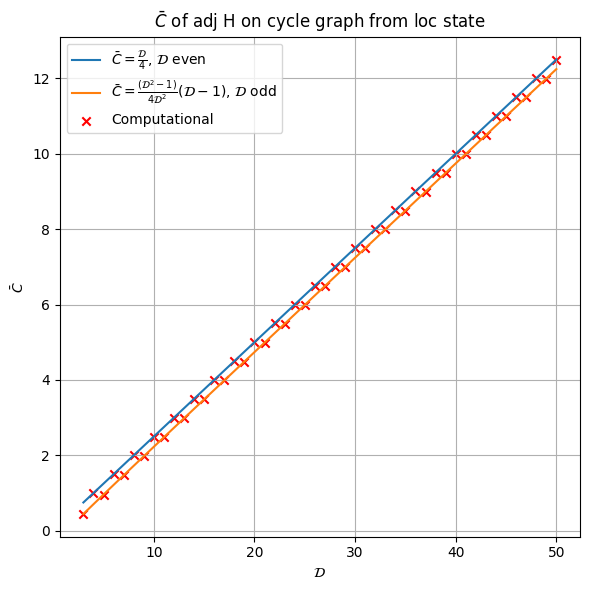

In [9]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.grid(True)
axx.plot(an_x,an_y_cycle_even, label=r"$\bar{C}=\frac{\mathcal{D}}{4}$, $\mathcal{D}$ even")
axx.plot(an_x,an_y_cycle_odd, label=r"$\bar{C}=\frac{(\mathcal{D}^2-1)}{4\mathcal{D}^2}(\mathcal{D}-1)$, $\mathcal{D}$ odd")
axx.scatter(an_x, compl_cycle, label="Computational", marker="x", color="r")
axx.set_title(r"$\bar{C}$ of adj H on cycle graph from loc state")
axx.set_ylabel(r"$\bar{C}$")
axx.set_xlabel(r"$\mathcal{D}$")
axx.legend()

In [10]:
#Now with complex, circulant cycles
d_max = 50
an_x = np.linspace(3, d_max, d_max-2, dtype=int)
an_y_circ_cycle = (an_x-1.)/2.

phase = np.pi/100
compl_circ_cycle = np.zeros(an_x.shape)
for i in an_x:
    H_circ_cycle = gen.circulant_cycle(i,phi=phase)
    initial = np.zeros(i, dtype=complex)
    initial[0] = 1.0+0.j
    #initial = np.ones(i, dtype=complex)
    new_H, compl_circ_cycle[i-3] = get_complexity(H_circ_cycle, initial)

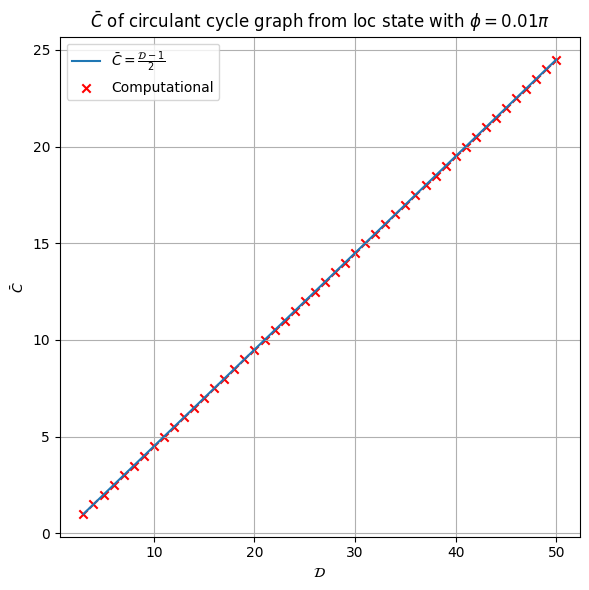

In [11]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.grid(True)
#axx.plot(an_x,an_y_cycle_even, label="Analytical even dim")
axx.plot(an_x,an_y_circ_cycle, label=r"$\bar{C}=\frac{\mathcal{D}-1}{2}$")
axx.scatter(an_x, compl_circ_cycle, label="Computational", marker="x", color="r")
axx.set_title(r"$\bar{C}$ of circulant cycle graph from loc state with"+f" $\phi=${phase/np.pi}$\pi$")
axx.set_ylabel(r"$\bar{C}$")
axx.set_xlabel(r"$\mathcal{D}$")
axx.legend()

# Testing generation of Random matrices

We test the generation and spectral distribution of $2\times2$ Hermitian matrices:
$$ \begin{bmatrix} a & b \\ b* & c \end{bmatrix}, $$

where $a,c\in [-1,1)$ are sampled uniformly, and $b\in \mathbb{C}$ is sampled uniformly in the unit complex disk. 

In [12]:
def distr_linear():
    y = np.random.random()
    return np.sqrt(y)

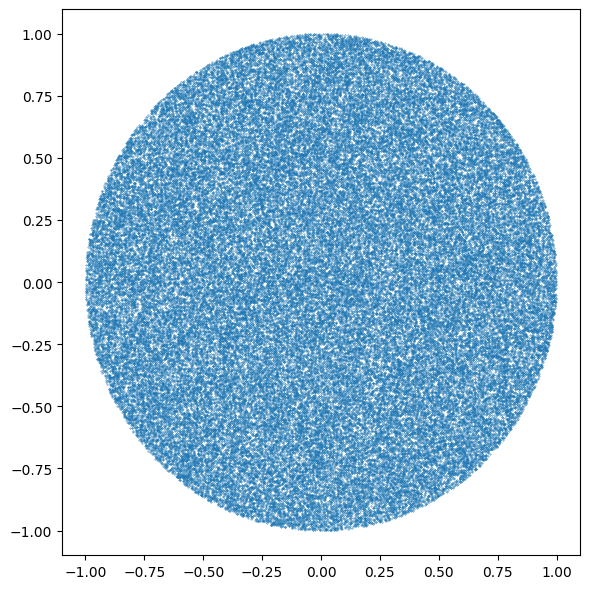

In [13]:
#Correctly sampling the unit disk

n_it = 100000
points = np.ndarray((2,n_it))
for i in range(n_it):
    rho = distr_linear()
    phi = np.random.uniform(0.,2*np.pi)
    points[0,i] = np.cos(phi)
    points[1,i] = np.sin(phi)
    points[:,i] *= rho


fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.scatter(x=points[0,:], y=points[1,:], s=0.1)

In [14]:
#Generate a random, hermitian, 2x2 matrix
np.random.seed(0)
rand = gen.uniform_herm(2)
print(rand)
#print(rand)
E = np.linalg.eigvalsh(rand)
print(E)
#print(np.conj(psi.T)@rand@psi)

[[ 0.4110535 +0.j         -0.16074443-0.72316992j]
 [-0.16074443+0.72316992j  0.17953273+0.j        ]]
[-0.45451617  1.04510241]


In [15]:
iterations = 100000
eigenvalues = np.ndarray((2,iterations))
gap = np.ndarray(iterations)

for i in range(iterations):
    E= np.linalg.eigvalsh(gen.uniform_herm(2))
    eigenvalues[:,i] = E
    gap[i] = np.abs(E[0]-E[1])

Text(0.5, 1.0, 'Eigenvalues')

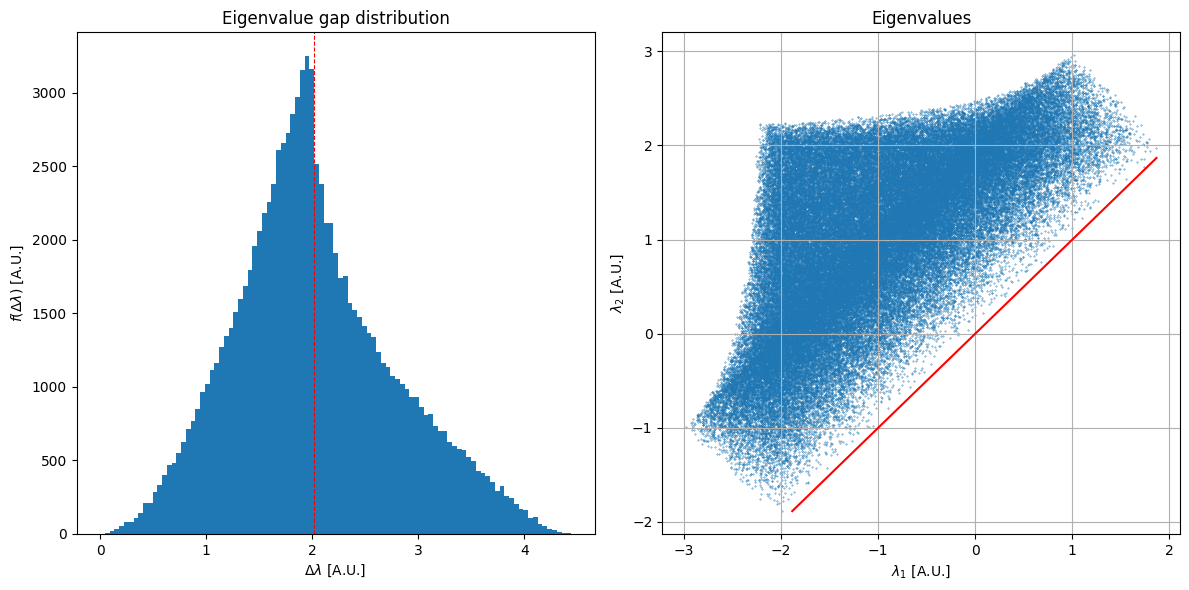

In [16]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

n_bins = 100
bins = np.linspace(start=0.,stop=gap.max(), num=n_bins)

axx[0].hist(gap, bins=bins)
axx[0].axvline(x=np.mean(gap), linestyle='--', color='r', linewidth=0.8)
axx[0].set_xlabel(r"$\Delta\lambda$ [A.U.]")
axx[0].set_ylabel(r"$f(\Delta\lambda)$ [A.U.]")
axx[0].set_title("Eigenvalue gap distribution")

x = np.linspace(start=np.min(eigenvalues[1]),stop=np.max(eigenvalues[0]), num=eigenvalues.shape[1])
axx[1].grid(True)
axx[1].scatter(eigenvalues[0], eigenvalues[1], s=0.1)
axx[1].plot(x, x, c="r")
axx[1].set_xlabel(r"$\lambda_1$ [A.U.]")
axx[1].set_ylabel(r"$\lambda_2$ [A.U.]")
axx[1].set_title("Eigenvalues")

In [17]:
#Gli autovalori restituiti da eigvalsh sono sempre in ordine crescente, per questo tutti i punti nel secondo grafico sono al di sopra della retta y=x. 
#(identificazione dei punti (x,y) e (y,x); se non sbaglio mappa su un nastro di Moebius)

In [18]:
iterations = 10000
#complexity of an ensemble of 2x2 hermitian matrices
compl_ensemble = np.zeros(iterations)

for i in range(iterations):
    rand = gen.uniform_herm(2)
    initial = np.zeros(2, dtype=complex)
    initial[0] = 1.0+0.j
    new_H, compl_ensemble[i] = get_complexity(rand, initial)

Text(0, 0.5, '$f(\\bar{C})$ [A.U.]')

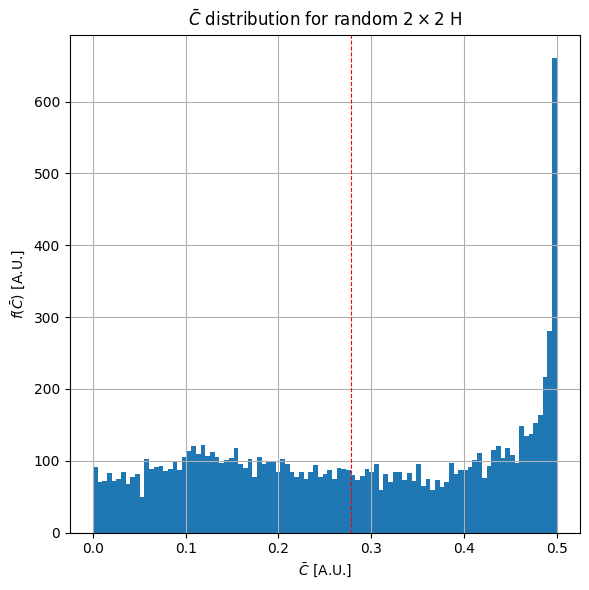

In [19]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

n_bins = 100
bins = np.linspace(start=0.,stop=compl_ensemble.max(), num=n_bins)

axx.grid(True)
axx.hist(compl_ensemble, bins=bins)
axx.axvline(x=np.mean(compl_ensemble), linestyle='--', color='r', linewidth=0.8)
axx.set_title(r"$\bar{C}$ distribution for random $2\times 2$ H")
axx.set_xlabel(r"$\bar{C}$ [A.U.]")
axx.set_ylabel(r"$f(\bar{C})$ [A.U.]")

# 1D Anderson model and spread complexity as a measure of localization

In [20]:
iterations = 10000
disorder = 0.5
np.random.seed(0)
eigens = np.ndarray(iterations)

for i in range(iterations):
    rand = gen.Anderson_H(50, W=disorder)
    E= np.linalg.eigvalsh(rand)
    eigens[i] = E[0]

#print(eigens)

In [21]:
def anderson_chain_ensemble(iterations, disorder, dim):
    eigens = np.ndarray(iterations)

    for i in range(iterations):
        rand = gen.Anderson_H(dim=dim, W=disorder)
        E= np.linalg.eigvalsh(rand)
        eigens[i] = E[0]
    
    return eigens

In [22]:
disorders = np.linspace(start=0.1, stop=2., num=6)
iterations = 10000
dim = 50
e_values = np.ndarray((disorders.size, iterations))
np.random.seed(0)
for i in range(disorders.size):
    e_values[i] = anderson_chain_ensemble(iterations=iterations, disorder=disorders[i], dim=dim)


In [23]:
print(disorders)

[0.1  0.48 0.86 1.24 1.62 2.  ]


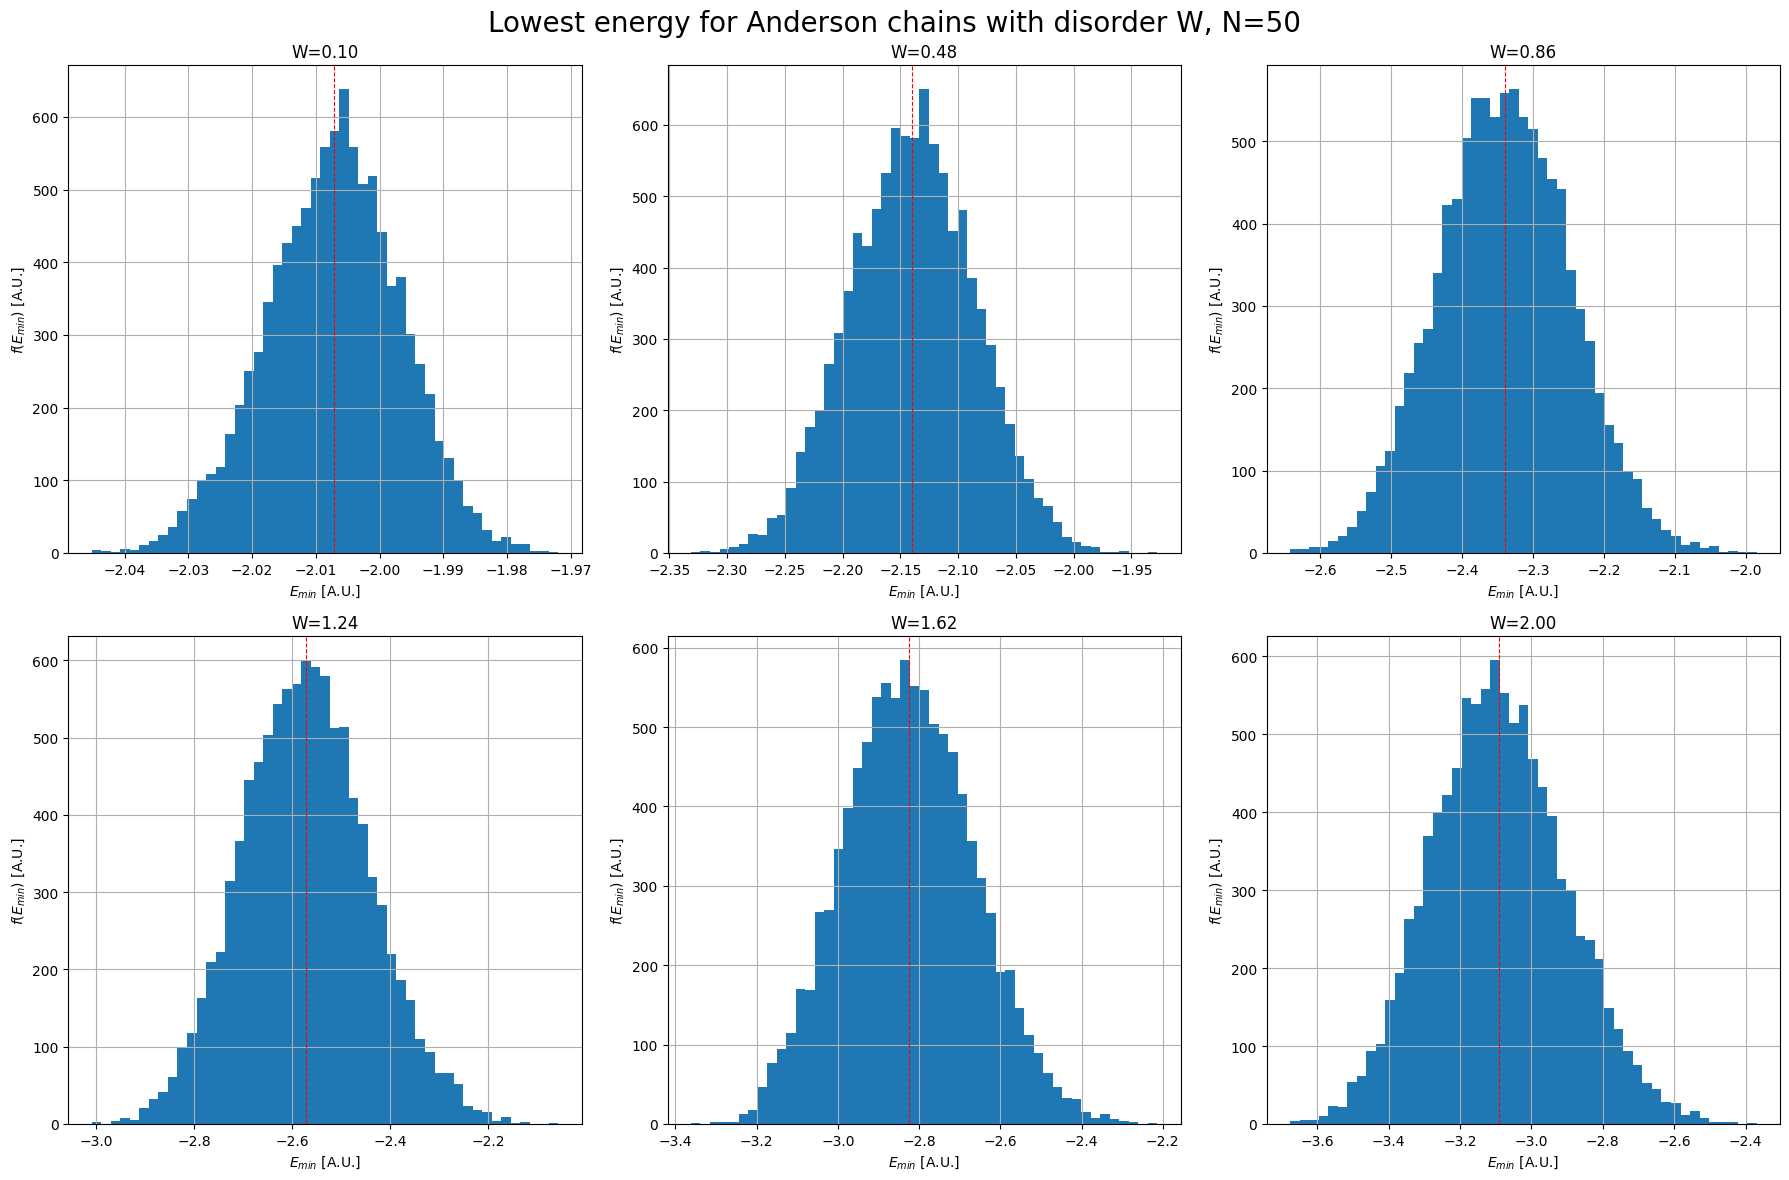

In [24]:

fig, axx = plt.subplots(2,3, figsize=(18,12), tight_layout=True)
fig.suptitle("Lowest energy for Anderson chains with disorder W, N="+f"{dim}", fontsize=20)
k = 0
for i in range(axx.shape[0]):
    for j in range(axx.shape[1]):
        eigens = e_values[k]
        n_bins = 50
        bins = np.linspace(start=eigens.min(),stop=eigens.max(), num=n_bins)
        axx[i][j].grid(True)
        axx[i][j].hist(eigens, bins=bins)
        axx[i][j].axvline(x=eigens.mean(), linestyle='--', color='r', linewidth=0.8)
        axx[i][j].set_title(f"W={format(disorders[k],'.2f')}")
        axx[i][j].set_xlabel(r"$E_{min}$ [A.U.]")
        axx[i][j].set_ylabel(r"$f(E_{min})$ [A.U.]")
        k+=1
plt.show()

In [25]:
"""
disorder = 0.5
iterations = 10000
dim = np.linspace(start=10, stop=100, num=10, dtype=int)
print(dim)
e_values = np.ndarray((dim.size, iterations))
np.random.seed(0)
for i in range(dim.size):
    e_values[i] = anderson_chain_ensemble(iterations=iterations, disorder=disorder, dim=dim[i])
"""

'\ndisorder = 0.5\niterations = 10000\ndim = np.linspace(start=10, stop=100, num=10, dtype=int)\nprint(dim)\ne_values = np.ndarray((dim.size, iterations))\nnp.random.seed(0)\nfor i in range(dim.size):\n    e_values[i] = anderson_chain_ensemble(iterations=iterations, disorder=disorder, dim=dim[i])\n'

In [26]:
"""
fig, axx = plt.subplots(3,3, figsize=(18,18), tight_layout=True)
fig.suptitle("Lowest energy for Anderson chains of dimension N, disorder W="+f"{disorder}", fontsize=20)
k = 0
for i in range(axx.shape[0]):
    for j in range(axx.shape[1]):
        eigens = e_values[k]
        n_bins = 50
        bins = np.linspace(start=eigens.min(),stop=eigens.max(), num=n_bins)
        axx[i][j].grid(True)
        axx[i][j].hist(eigens, bins=bins)
        axx[i][j].axvline(x=eigens.mean(), linestyle='--', color='r', linewidth=0.8)
        axx[i][j].set_title(f"N={format(dim[k],'.2f')}")
        axx[i][j].set_xlabel(r"$E_{min}$ [A.U.]")
        axx[i][j].set_ylabel(r"$f(E_{min})$ [A.U.]")
        k+=1
plt.show()
"""

'\nfig, axx = plt.subplots(3,3, figsize=(18,18), tight_layout=True)\nfig.suptitle("Lowest energy for Anderson chains of dimension N, disorder W="+f"{disorder}", fontsize=20)\nk = 0\nfor i in range(axx.shape[0]):\n    for j in range(axx.shape[1]):\n        eigens = e_values[k]\n        n_bins = 50\n        bins = np.linspace(start=eigens.min(),stop=eigens.max(), num=n_bins)\n        axx[i][j].grid(True)\n        axx[i][j].hist(eigens, bins=bins)\n        axx[i][j].axvline(x=eigens.mean(), linestyle=\'--\', color=\'r\', linewidth=0.8)\n        axx[i][j].set_title(f"N={format(dim[k],\'.2f\')}")\n        axx[i][j].set_xlabel(r"$E_{min}$ [A.U.]")\n        axx[i][j].set_ylabel(r"$f(E_{min})$ [A.U.]")\n        k+=1\nplt.show()\n'

In [27]:
iterations = 10000
disorder = 0.5
#complexity of an ensemble of 2x2 hermitian matrices
compl_ensemble = np.zeros(iterations)

for i in range(iterations):
    rand = gen.Anderson_H(10, W=disorder)
    initial = np.zeros(10, dtype=complex)
    initial[0] = 1.0+0.j
    new_H, compl_ensemble[i] = get_complexity(rand, initial)

In [28]:
def anderson_compl_ensemble(iterations, disorder, dim, initial):
    compl_ensemble = np.zeros(iterations)

    for i in range(iterations):
        rand = gen.Anderson_H(dim=dim, W=disorder)
        new_H, compl_ensemble[i] = kr.get_complexity(rand, initial)
    
    return compl_ensemble

In [29]:
"""
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

n_bins = 100
bins = np.linspace(start=0.,stop=compl_ensemble.max(), num=n_bins)

axx.grid(True)
axx.hist(compl_ensemble, bins=bins)
axx.axvline(x=np.mean(compl_ensemble), linestyle='--', color='r', linewidth=0.8)
axx.set_title(r"$\bar{C}$ distribution for Anderson with N="+f"{10} and W={disorder}")
axx.set_xlabel(r"$\bar{C}$ [A.U.]")
axx.set_ylabel(r"$f(\bar{C})$ [A.U.]")
plt.show()
"""

'\nfig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)\n\nn_bins = 100\nbins = np.linspace(start=0.,stop=compl_ensemble.max(), num=n_bins)\n\naxx.grid(True)\naxx.hist(compl_ensemble, bins=bins)\naxx.axvline(x=np.mean(compl_ensemble), linestyle=\'--\', color=\'r\', linewidth=0.8)\naxx.set_title(r"$\x08ar{C}$ distribution for Anderson with N="+f"{10} and W={disorder}")\naxx.set_xlabel(r"$\x08ar{C}$ [A.U.]")\naxx.set_ylabel(r"$f(\x08ar{C})$ [A.U.]")\nplt.show()\n'

In [30]:
disorders = np.linspace(start=0.1, stop=5., num=9)
iterations = 10000
dim = 10
compl_values = np.ndarray((disorders.size, iterations))

np.random.seed(0)
initial = np.zeros(dim, dtype=complex)
initial[0] = 1.0+0.j
for i in range(disorders.size):
    compl_values[i] = anderson_compl_ensemble(iterations=iterations, disorder=disorders[i], dim=dim, initial=initial)

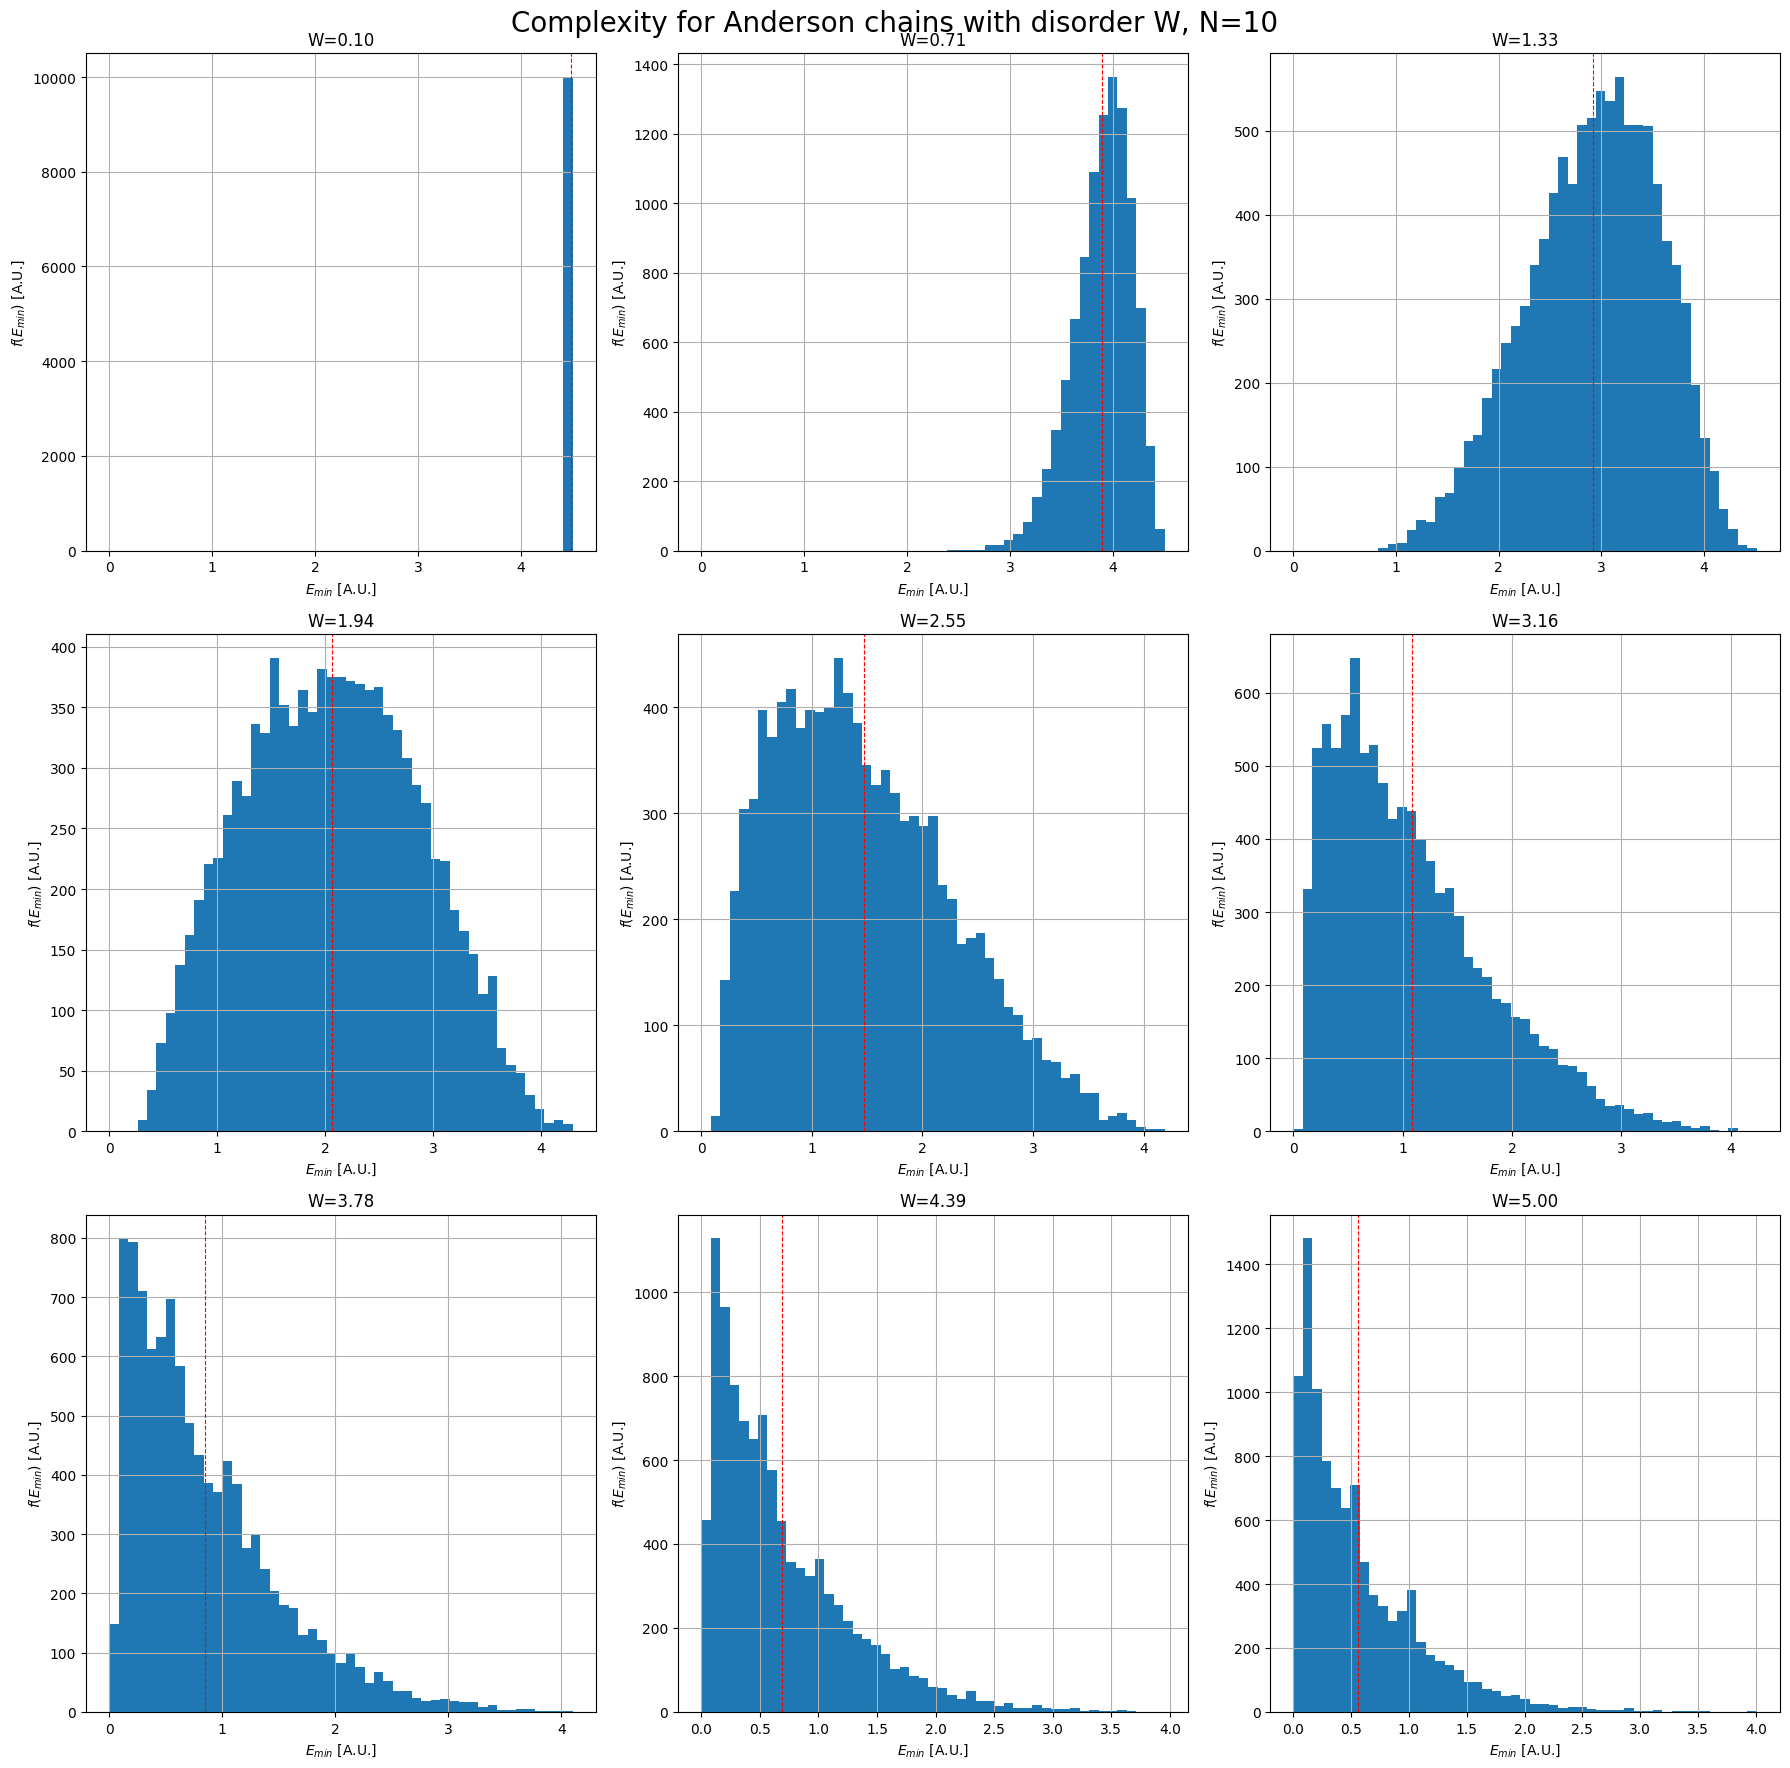

In [31]:
fig, axx = plt.subplots(3,3, figsize=(18,18), tight_layout=True)
fig.suptitle("Complexity for Anderson chains with disorder W, N="+f"{dim}", fontsize=20)
k = 0
for i in range(axx.shape[0]):
    for j in range(axx.shape[1]):
        compls = compl_values[k]
        n_bins = 50
        bins = np.linspace(start=0.,stop=compls.max(), num=n_bins)
        axx[i][j].grid(True)
        axx[i][j].hist(compls, bins=bins)
        axx[i][j].axvline(x=compls.mean(), linestyle='--', color='r', linewidth=0.8)
        axx[i][j].set_title(f"W={format(disorders[k],'.2f')}")
        axx[i][j].set_xlabel(r"$E_{min}$ [A.U.]")
        axx[i][j].set_ylabel(r"$f(E_{min})$ [A.U.]")
        k+=1
plt.show()

One can notice that the complexity decreases as the magnitude of disorder is increased; this is a reflection of well known localization of eigenstates of Anderson chains. Complexity can be used as a probe of localization of a dynamics.

In [32]:
av = np.array([np.mean(compl_values[i]) for i in range(disorders.size)])

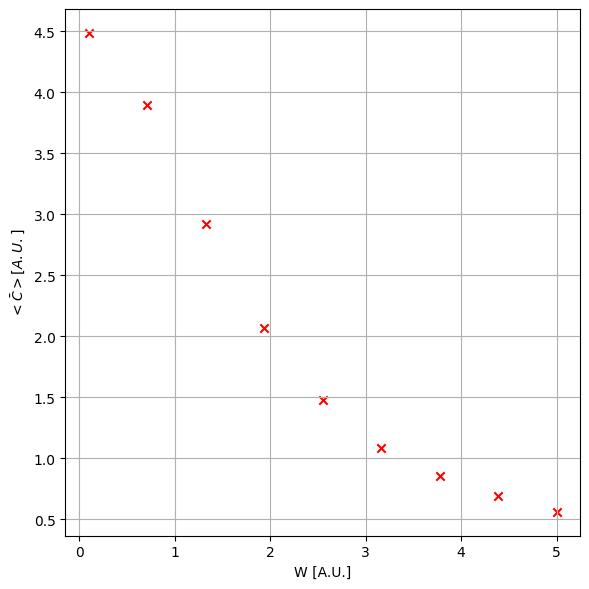

In [33]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.scatter(disorders, av, marker="x", color="r")
#axx.set_title()
axx.set_xlabel("W [A.U.]")
axx.set_ylabel(r"$<\bar{C}> [A.U.]$")
axx.grid(True)

Ora con uno stato iniziale localizzato, non giacente sull'estremità della catena

In [34]:
disorders = np.linspace(start=0.1, stop=5., num=9)
iterations = 10000
dim = 10
compl_values = np.ndarray((disorders.size, iterations))

np.random.seed(0)
initial = np.zeros(dim, dtype=complex)
initial[int(dim/2)] = 1.0+0.j
for i in range(disorders.size):
    compl_values[i] = anderson_compl_ensemble(iterations=iterations, disorder=disorders[i], dim=dim, initial=initial)

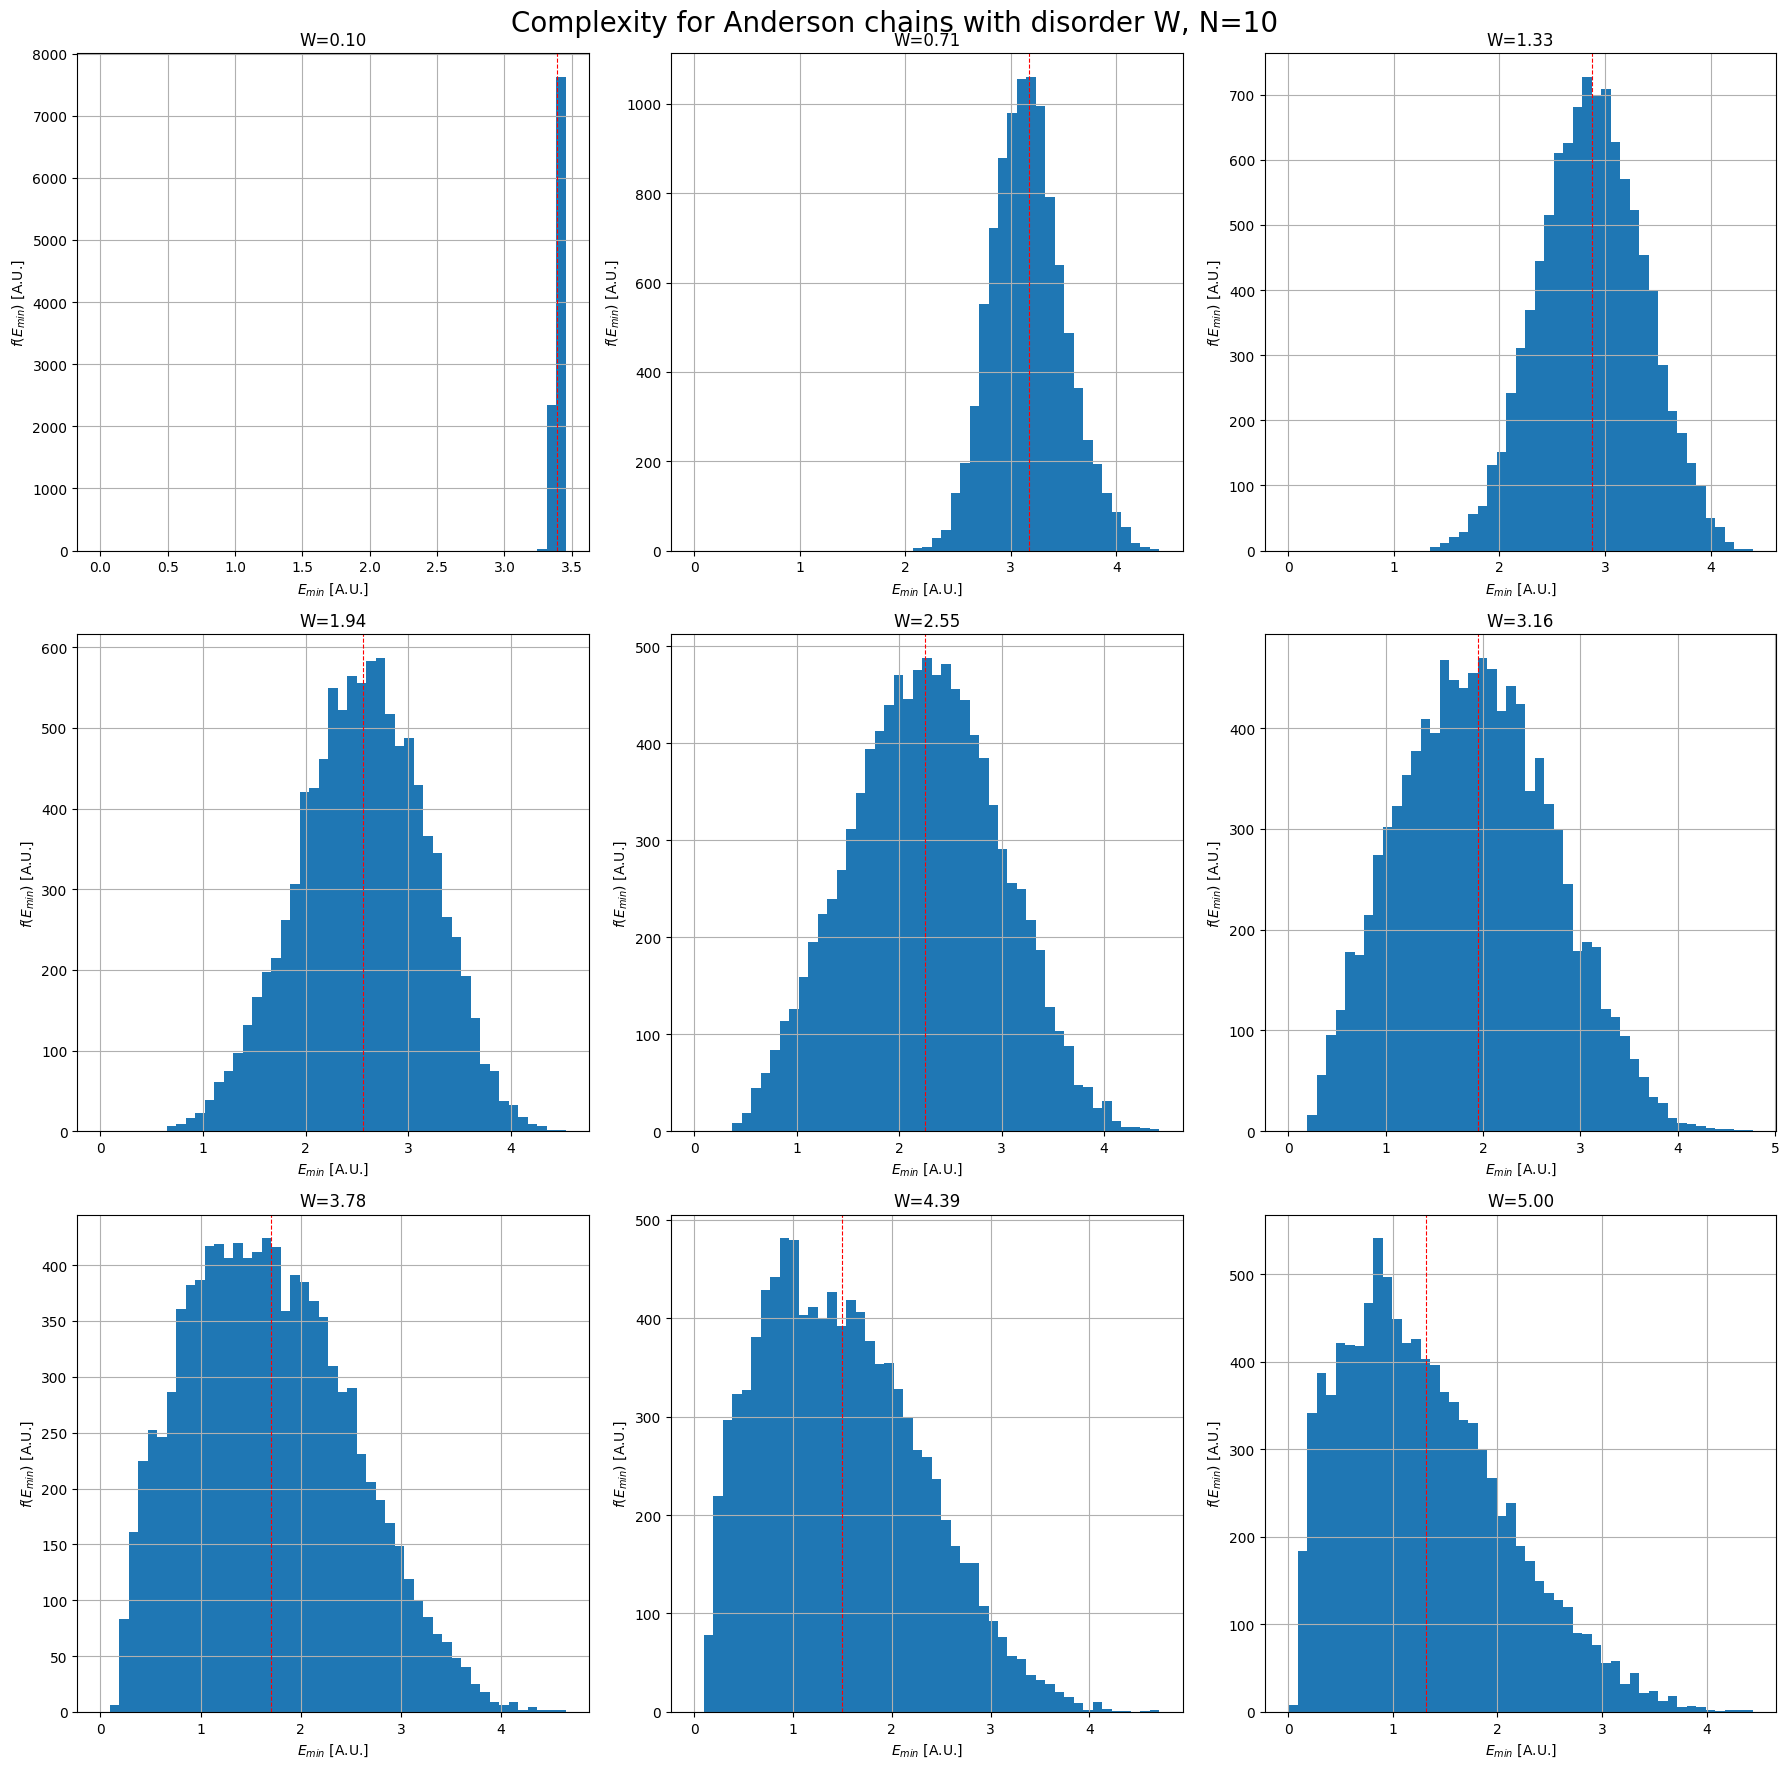

In [35]:
fig, axx = plt.subplots(3,3, figsize=(18,18), tight_layout=True)
fig.suptitle("Complexity for Anderson chains with disorder W, N="+f"{dim}", fontsize=20)
k = 0
for i in range(axx.shape[0]):
    for j in range(axx.shape[1]):
        compls = compl_values[k]
        n_bins = 50
        bins = np.linspace(start=0.,stop=compls.max(), num=n_bins)
        axx[i][j].grid(True)
        axx[i][j].hist(compls, bins=bins)
        axx[i][j].axvline(x=compls.mean(), linestyle='--', color='r', linewidth=0.8)
        axx[i][j].set_title(f"W={format(disorders[k],'.2f')}")
        axx[i][j].set_xlabel(r"$E_{min}$ [A.U.]")
        axx[i][j].set_ylabel(r"$f(E_{min})$ [A.U.]")
        k+=1
plt.show()

In [36]:
av = np.array([np.mean(compl_values[i]) for i in range(disorders.size)])

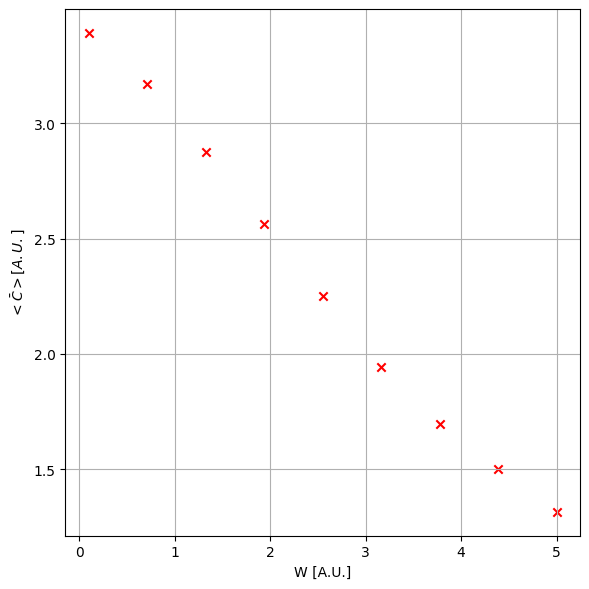

In [37]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.scatter(disorders, av, marker="x", color="r")
#axx.set_title()
axx.set_xlabel("W [A.U.]")
axx.set_ylabel(r"$<\bar{C}> [A.U.]$")
axx.grid(True)